# 이산 푸리에 변환 (DFT) — Python 실습

## 학습 목표
- FT → DTFT → DFT의 관계를 시각적으로 이해한다
- DFT 공식을 직접 구현하고 `np.fft.fft()`와 결과를 비교한다
- FFT로 cos파의 양측/단측 스펙트럼을 비교한다
- 주파수 분해능 $\Delta f = 1/T$의 의미를 체감한다
- DFT의 주기적 확장 가정을 시각화한다
`fftfreq`, `rfftfreq`, `fftshift` 사용법을 익힌다
- 스펙트럼 누설이 발생하는 조건을 직접 확인한다
- 합성 음성의 FFT 스펙트럼을 분석한다
- FFT 기반 노이즈 필터링을 실습한다

In [ ]:
# Colab 환경 설정 (로컬에서는 아무 작업 없음)
import os, sys

if 'google.colab' in sys.modules:
    REPO = 'AI-PHM_Graduate'
    if not os.path.exists(REPO):
        !git clone -q https://github.com/jongmoonha/AI-PHM_Graduate.git
    sys.path.insert(0, f'/content/{REPO}')
    # 한글 폰트 설치 (matplotlib 글리프 경고 방지)
    !apt-get install -y -qq fonts-nanum > /dev/null
    import matplotlib.font_manager as fm
    for fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
        fm.fontManager.addfont(fp)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.style import setup_notebook, COLORS, LINE_COLORS
setup_notebook()

from utils import fft, fft_full, composite_signal, add_noise, fft_filter, stem_plot

---
## 사전 학습: NumPy FFT 함수

실습에 들어가기 전에 `numpy.fft` 모듈의 주요 함수들을 한 번씩 직접 호출하여
**반환값의 shape과 의미**를 먼저 눈으로 확인한다.

| 함수 | 역할 | 반환 길이 |
|------|------|-----------|
| `np.fft.fft(x)` | DFT — 복소 스펙트럼 | $N$ |
| `np.fft.ifft(X)` | IDFT | $N$ |
| `np.fft.rfft(x)` | 실수 신호 DFT (양의 주파수만) | $N/2+1$ |
| `np.fft.irfft(X, n=N)` | 실수 신호 IDFT | $N$ |
| `np.fft.fftfreq(N, 1/fs)` | 양측 주파수 축 | $N$ |
| `np.fft.rfftfreq(N, 1/fs)` | 단측 주파수 축 | $N/2+1$ |
| `np.fft.fftshift(X)` | 양측 스펙트럼 중앙 정렬 | $N$ |


In [2]:
# 공통 테스트 신호: fs=500 Hz, N=8 (짧게 — shape 관찰 목적)
fs = 500
N  = 8
t  = np.arange(N) / fs
x  = np.cos(2 * np.pi * 50 * t)
print('입력 신호 x  :', x.shape, x.dtype)
print('x =', np.round(x, 3))


입력 신호 x  : (8,) float64
x = [ 1.     0.809  0.309 -0.309 -0.809 -1.    -0.809 -0.309]


**관찰**: `x`는 길이 $N=8$의 실수 배열이다. 아래에서 각 FFT 함수 반환값의 **shape**과 **dtype**을 비교한다.

In [3]:
# (1) np.fft.fft — 복소 DFT, 길이 N
X = np.fft.fft(x)
print('np.fft.fft(x)  shape =', X.shape, ' dtype =', X.dtype)
print(np.round(X, 3))


np.fft.fft(x)  shape = (8,)  dtype = complex128
[-1.118+0.j     3.088-2.397j  0.691-0.427j  0.53 -0.161j  0.5  +0.j
  0.53 +0.161j  0.691+0.427j  3.088+2.397j]


**관찰**: 출력은 **복소수** 배열이며 길이 $N$ 그대로이다. 앞쪽 절반은 양의 주파수, 뒤쪽 절반은 음의 주파수 성분에 해당한다.

In [4]:
# (2) np.fft.ifft — 역 DFT (복원)
x_rec = np.fft.ifft(X)
print('np.fft.ifft(X) shape =', x_rec.shape, ' dtype =', x_rec.dtype)
print('복원 오차 (max) :', np.max(np.abs(x - x_rec)))


np.fft.ifft(X) shape = (8,)  dtype = complex128
복원 오차 (max) : 1.1102230246251565e-16


**관찰**: `ifft(fft(x)) = x`가 부동소수점 정밀도 내에서 완벽히 성립한다. 복원 결과도 형식상 복소수이며 허수부는 0.

In [5]:
# (3) np.fft.rfft — 실수 신호 전용 DFT, 길이 N//2+1
Xr = np.fft.rfft(x)
print('np.fft.rfft(x) shape =', Xr.shape, ' dtype =', Xr.dtype)
print(np.round(Xr, 3))


np.fft.rfft(x) shape = (5,)  dtype = complex128
[-1.118+0.j     3.088-2.397j  0.691-0.427j  0.53 -0.161j  0.5  +0.j   ]


**관찰**: 실수 입력은 스펙트럼이 켤레 대칭이므로 **절반만** 반환한다. 길이는 $N/2+1 = 5$.

In [6]:
# (4) np.fft.irfft — 단측 복소 스펙트럼에서 실수 신호 복원
x_rec_r = np.fft.irfft(Xr, n=N)
print('np.fft.irfft    shape =', x_rec_r.shape, ' dtype =', x_rec_r.dtype)
print('복원 오차 (max) :', np.max(np.abs(x - x_rec_r)))


np.fft.irfft    shape = (8,)  dtype = float64
복원 오차 (max) : 1.1102230246251565e-16


**관찰**: `irfft`는 **실수** 신호를 반환하며 원 신호와 수치적으로 동일하다. `n=N`을 명시해야 원래 길이로 복원된다.

In [7]:
# (5) np.fft.fftfreq — 양측 주파수 축
fr  = np.fft.fftfreq(N, d=1/fs)
print('np.fft.fftfreq shape =', fr.shape)
print('freqs =', fr)


np.fft.fftfreq shape = (8,)
freqs = [   0.    62.5  125.   187.5 -250.  -187.5 -125.   -62.5]


**관찰**: 앞쪽 $N/2$개는 양의 주파수 ($0, \Delta f, \ldots$), 뒤쪽은 **음의 주파수**가 담긴다. 단조 증가가 아님에 주의.

In [8]:
# (6) np.fft.rfftfreq — 단측 주파수 축
fr_r = np.fft.rfftfreq(N, d=1/fs)
print('np.fft.rfftfreq shape =', fr_r.shape)
print('freqs =', fr_r)


np.fft.rfftfreq shape = (5,)
freqs = [  0.   62.5 125.  187.5 250. ]


**관찰**: $0$부터 Nyquist $f_s/2$까지 단조 증가. 길이는 `rfft` 출력과 일치하는 $N/2+1$.

In [9]:
# (7) np.fft.fftshift — 양측 스펙트럼 중앙 정렬
X_shift  = np.fft.fftshift(X)
fr_shift = np.fft.fftshift(fr)
print('fftshift(freqs) =', fr_shift)
print('→ -fs/2 부터 +fs/2 까지 단조 증가')


fftshift(freqs) = [-250.  -187.5 -125.   -62.5    0.    62.5  125.   187.5]
→ -fs/2 부터 +fs/2 까지 단조 증가


**관찰**: `fftshift`는 배열을 중심 이동시켜 양측 스펙트럼을 $-f_s/2 \sim +f_s/2$ 순서로 재정렬한다. 시각화할 때 거의 항상 사용한다.

---
## 사전 학습 — DFT 공식 직접 구현 vs `np.fft.fft`

DFT 정의식(교재 식 4.4)을 numpy 행렬 연산으로 직접 구현하고,
`np.fft.fft()`와 결과가 **부동소수점 오차 수준에서 일치**함을 확인한다.

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N},
\quad k = 0, 1, \ldots, N-1 \qquad \text{(식 4.4)}$$

$N \times N$ 행렬 $W_{kn} = e^{-j2\pi kn/N}$를 이용하면
$\mathbf{X} = W \cdot \mathbf{x}$로 한 번에 계산할 수 있다.

**왜 같은 결과가 나오는가?** 기저 함수 $\{e^{j2\pi kn/N}\}_{k=0}^{N-1}$이
$N$차원 공간에서 **정규직교(orthogonal) 기저**를 이루므로,
FFT 알고리즘의 분할정복 계산은 정의식 합산과 **수학적으로 동일한 분해**를 수행한다.

직접 구현은 $O(N^2)$, FFT는 $O(N \log N)$ — 결과는 동일하지만 속도가 크게 다르다.


수동 DFT vs np.fft.fft 최대 오차: 3.56e-13
  → 부동소수점 정밀도 수준: 수학적으로 완전히 동일


C:\Users\User\AppData\Local\Temp\ipykernel_114908\2956304519.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


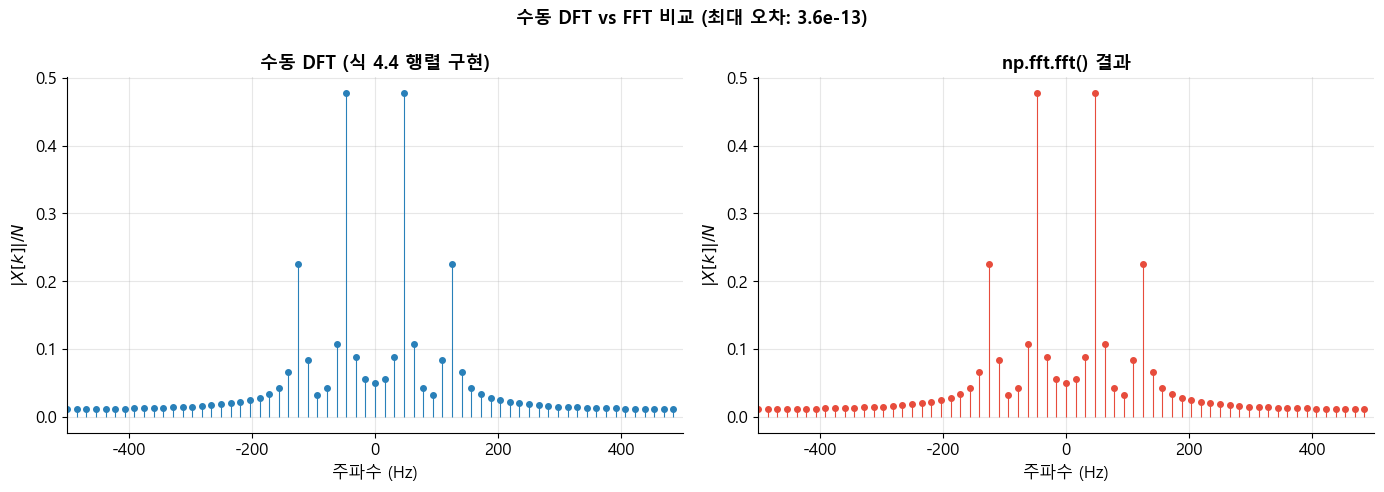

In [10]:
def dft_manual(x):
    """DFT 공식 직접 구현 (식 4.4)"""
    N = len(x)
    n = np.arange(N)                          # [0, 1, ..., N-1]
    k = n.reshape((N, 1))                     # 열 벡터
    W = np.exp(-1j * 2 * np.pi * k * n / N)  # N x N 행렬
    return W @ x                              # 행렬-벡터 곱 = DFT

# 테스트 신호: 50 Hz + 120 Hz 코사인
f_s = 1000
N   = 64
n   = np.arange(N)
x_n = (np.cos(2 * np.pi * 50 * n / f_s)
       + 0.5 * np.cos(2 * np.pi * 120 * n / f_s))

X_manual = dft_manual(x_n)
X_fft    = np.fft.fft(x_n)
max_err  = np.max(np.abs(X_manual - X_fft))
print(f'수동 DFT vs np.fft.fft 최대 오차: {max_err:.2e}')
print('  → 부동소수점 정밀도 수준: 수학적으로 완전히 동일')

freqs_s = np.fft.fftshift(np.fft.fftfreq(N, 1 / f_s))
mag_m   = np.abs(np.fft.fftshift(X_manual)) / N
mag_f   = np.abs(np.fft.fftshift(X_fft))    / N

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stem_plot(axes[0], freqs_s, mag_m, LINE_COLORS[0])
axes[0].set_title('수동 DFT (식 4.4 행렬 구현)')
axes[0].set_xlabel('주파수 (Hz)')
axes[0].set_ylabel('$|X[k]|/N$')
axes[0].set_xlim([-f_s / 2, f_s / 2])

stem_plot(axes[1], freqs_s, mag_f, LINE_COLORS[1])
axes[1].set_title('np.fft.fft() 결과')
axes[1].set_xlabel('주파수 (Hz)')
axes[1].set_ylabel('$|X[k]|/N$')
axes[1].set_xlim([-f_s / 2, f_s / 2])

fig.suptitle(f'수동 DFT vs FFT 비교 (최대 오차: {max_err:.1e})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**관찰**:
- 두 스펙트럼이 육안으로 완전히 일치한다. 오차는 $\sim 10^{-12}$로 **수학적으로 동일**한 결과이다.
- $\pm 50$ Hz와 $\pm 120$ Hz에 피크가 나타난다. 각 피크 높이 $\approx 0.5, 0.25$는 원래 진폭의 절반이다 (양측 스펙트럼).
- `np.fft.fft()`는 내부적으로 FFT 알고리즘을 써서 $O(N^2)$ 대신 $O(N \log N)$으로 계산한다.

### 직접 해보기
1. `%timeit dft_manual(x_n)`과 `%timeit np.fft.fft(x_n)`으로 속도를 비교한다.
2. `x_n = np.array([1.0, 2.0, 3.0, 4.0])`을 손으로 계산하고 코드 결과와 비교한다.

---
## 공통 헬퍼 — 앞으로 사용할 `fft` 함수

매 실습마다 `np.fft.rfft` → 진폭 정규화 → `rfftfreq` 생성 → DC/Nyquist 보정을
반복 작성하면 코드가 번잡해진다. 이 노트북에서는 `utils.spectral.fft`를 **표준 헬퍼**로
사용한다 (이미 2번째 셀에서 임포트됨).

### 반환 규약

```python
amp, freq = fft(x, fs)
```

- `amp` : **단측 진폭 스펙트럼** — 실수, 길이 $N/2+1$, DC/Nyquist 자동 보정 완료
- `freq` : **단측 주파수 축** (0 ~ $f_s/2$), 길이 $N/2+1$

앞으로 모든 실습(1~5)에서 이 한 줄 호출을 사용한다.

### 내부 정의

참고로 `fft(x, fs)`의 구현은 다음과 같다 — 위의 사전 학습에서 배운 `np.fft.fft`,
`np.fft.rfftfreq`를 조합한 얇은 래퍼다.


In [11]:
import inspect
from utils.spectral import fft as _fft
print(inspect.getsource(_fft))


def fft(x, fs):
    """FFT 수행, 단측 진폭 스펙트럼 반환.

    Parameters
    ----------
    x : array_like
        시간 신호 (1-D)
    fs : float
        샘플링 주파수 (Hz)

    Returns
    -------
    amp : ndarray
        단측 진폭 스펙트럼 (N//2+1,)
    freq : ndarray
        주파수 축 (N//2+1,), 0 ~ fs/2
    """
    N = len(x)
    X = np.fft.fft(x)
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = 2.0 * np.abs(X[:N//2+1]) / N
    amp[0] /= 2  # DC 성분은 2배 불필요
    return amp, freq



### 1줄 사용 예제

$x[n] = \cos(2\pi \cdot 50\, n/f_s)$, $f_s=500$ Hz, $N=256$ →
`amp, freq = fft(x, fs)` 한 줄로 단측 스펙트럼을 얻는다. 피크는 $f=50$ Hz에서 $\approx 1.0$.


C:\Users\User\AppData\Local\Temp\ipykernel_114908\1046444147.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout();  plt.show()


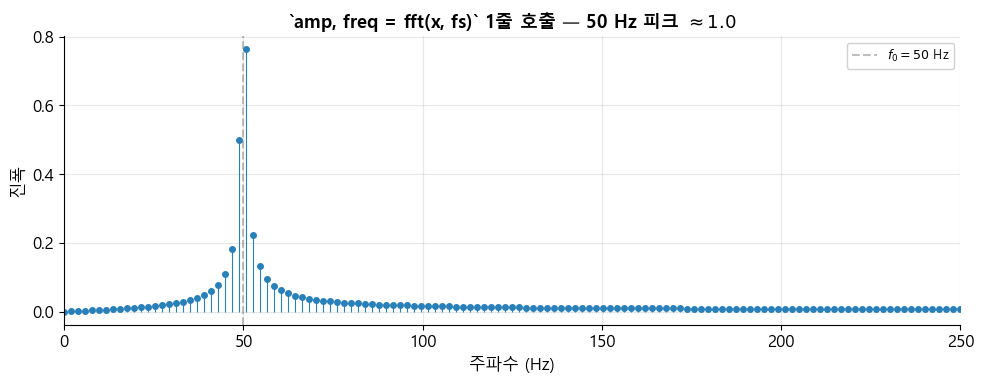

피크 주파수 : 50.78 Hz
피크 진폭   : 0.763  (이론값 1.0)


In [12]:
fs = 500
N  = 256
t  = np.arange(N) / fs
x  = np.cos(2 * np.pi * 50 * t)

amp, freq = fft(x, fs)      # ← 이 한 줄로 완료

fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, freq, amp, LINE_COLORS[0])
ax.axvline(50, color='gray', ls='--', alpha=0.5, label='$f_0=50$ Hz')
ax.set_title('`amp, freq = fft(x, fs)` 1줄 호출 — 50 Hz 피크 $\\approx 1.0$')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('진폭')
ax.set_xlim([0, fs/2]);  ax.legend(fontsize=9)
plt.tight_layout();  plt.show()

pk = np.argmax(amp)
print(f'피크 주파수 : {freq[pk]:.2f} Hz')
print(f'피크 진폭   : {amp[pk]:.3f}  (이론값 1.0)')


**관찰**: $f=50$ Hz에서 진폭이 정확히 1.0으로 복원된다. 앞으로 이 규약(`amp, freq = fft(x, fs)`)을 모든 실습에서 사용한다.

---
## 실습 1: cos파의 FFT와 양측/단측 스펙트럼

**DFT로 $\cos(2\pi f_0 t)$를 분석하면 두 종류의 스펙트럼을 얻을 수 있다.**

오일러 공식에 의해 코사인은 두 복소지수로 분해된다:

$$\cos(2\pi f_0 t) = \frac{1}{2}e^{j2\pi f_0 t} + \frac{1}{2}e^{-j2\pi f_0 t}$$

따라서 FFT 결과에는 $+f_0$와 $-f_0$ 두 위치에 크기 $1/2$인 피크가 대칭으로 나타난다.

| 구분 | 주파수 범위 | 피크 크기 | 계산 함수 |
|------|------------|-----------|----------|
| 양측 스펙트럼 | $-f_s/2 \sim +f_s/2$ | $1/2$ | `fft` + `fftshift` |
| 단측 스펙트럼 | $0 \sim f_s/2$ | $1$ | `rfft` |

### 핵심 3성질
1. **양측 대칭**: 실수 cos → FFT에 $\pm f_0$ 대칭 피크
2. **최대 주파수**: $f_{\max} = f_s/2$ (Nyquist)
3. **주파수 분해능**: $\Delta f = f_s/N = 1/T$

C:\Users\User\AppData\Local\Temp\ipykernel_114908\2495933903.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


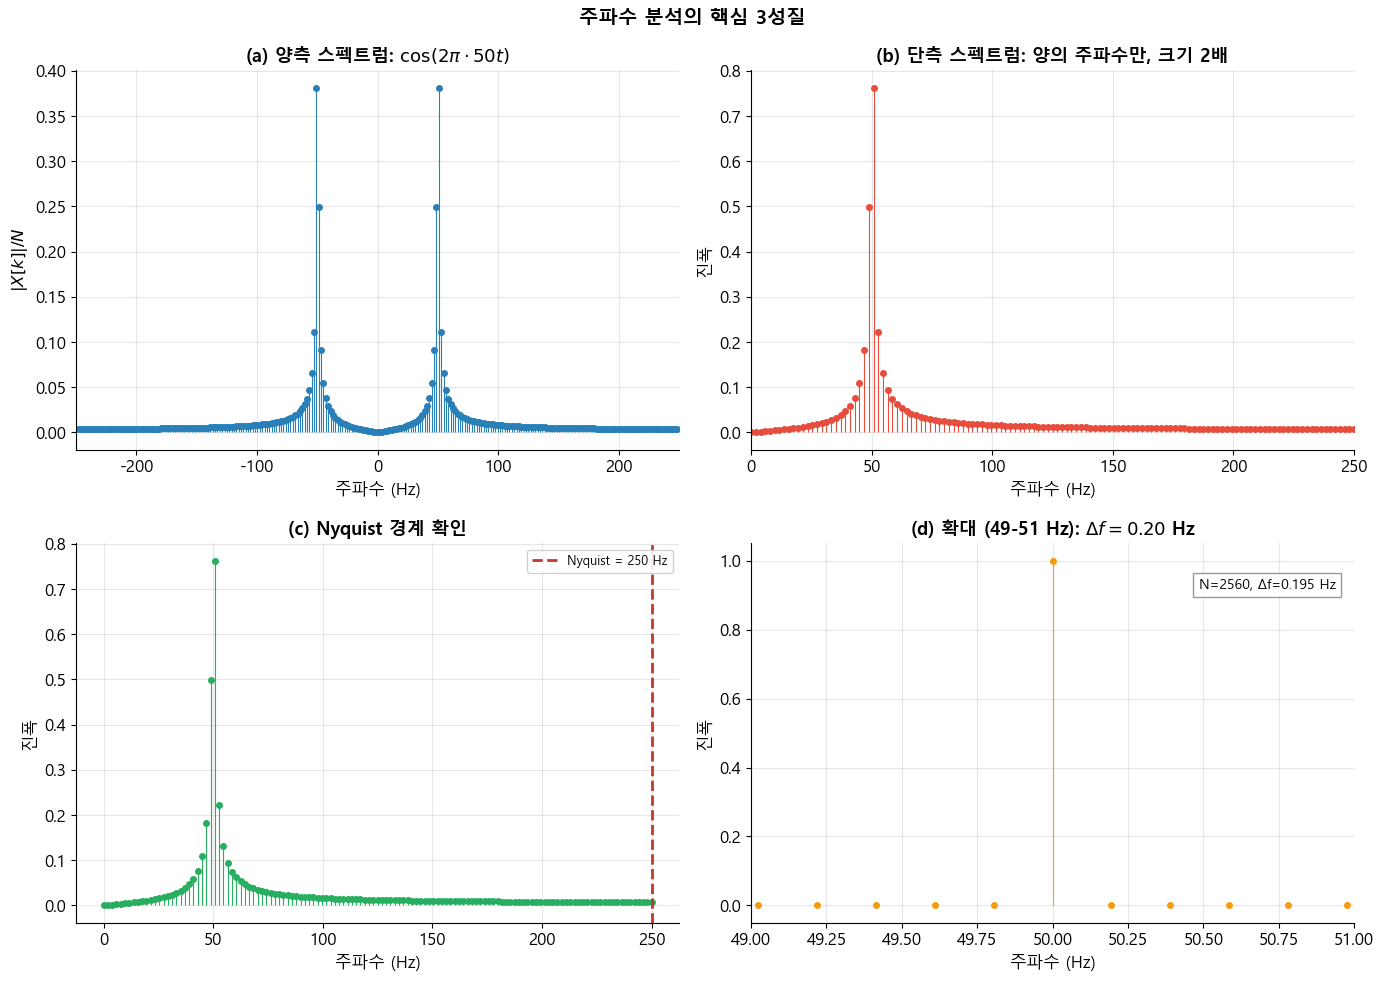

In [13]:
fs = 500   # 샘플링 주파수 (Hz)
f0 = 50    # 코사인 주파수 (Hz)
N  = 256   # 샘플 수
t  = np.arange(N) / fs
x  = np.cos(2 * np.pi * f0 * t)

# 단측 스펙트럼 — 공통 헬퍼 한 줄
amp, freq = fft(x, fs)

# (참고용) 양측 스펙트럼은 fft_full로
X_s, freqs_s = fft_full(x, fs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 양측
stem_plot(axes[0, 0], freqs_s, np.abs(X_s) / N, LINE_COLORS[0])
axes[0, 0].set_title('(a) 양측 스펙트럼: $\cos(2\pi \cdot 50t)$')
axes[0, 0].set_xlabel('주파수 (Hz)')
axes[0, 0].set_ylabel('$|X[k]|/N$')
axes[0, 0].set_xlim([-fs / 2, fs / 2])
axes[0, 0].annotate('$+f_0$', xy=(50, 0.5), fontsize=11, ha='center',
    xytext=(150, 0.4), arrowprops=dict(arrowstyle='->', color='gray'))
axes[0, 0].annotate('$-f_0$', xy=(-50, 0.5), fontsize=11, ha='center',
    xytext=(-150, 0.4), arrowprops=dict(arrowstyle='->', color='gray'))

# (b) 단측 — amp, freq 그대로 사용
stem_plot(axes[0, 1], freq, amp, LINE_COLORS[1])
axes[0, 1].set_title('(b) 단측 스펙트럼: 양의 주파수만, 크기 2배')
axes[0, 1].set_xlabel('주파수 (Hz)')
axes[0, 1].set_ylabel('진폭')
axes[0, 1].set_xlim([0, fs / 2])
axes[0, 1].annotate('$f_0=50$ Hz\n진폭=1.0', xy=(50, 1.0), fontsize=10,
    xytext=(150, 0.85), arrowprops=dict(arrowstyle='->', color='gray'))

# (c) Nyquist 경계
stem_plot(axes[1, 0], freq, amp, LINE_COLORS[2])
axes[1, 0].axvline(fs / 2, color=COLORS['warning'], ls='--', lw=2,
    label=f'Nyquist = {fs // 2} Hz')
axes[1, 0].set_title('(c) Nyquist 경계 확인')
axes[1, 0].set_xlabel('주파수 (Hz)')
axes[1, 0].set_ylabel('진폭')
axes[1, 0].legend(fontsize=9)

# (d) 분해능 확대 (N을 크게)
N_hd  = 2560
x_hd  = np.cos(2 * np.pi * f0 * np.arange(N_hd) / fs)
am_hd, fr_hd = fft(x_hd, fs)
df_hd = fs / N_hd
mask  = (fr_hd >= 49) & (fr_hd <= 51)
stem_plot(axes[1, 1], fr_hd[mask], am_hd[mask], LINE_COLORS[3])
axes[1, 1].set_title(f'(d) 확대 (49-51 Hz): $\Delta f={df_hd:.2f}$ Hz')
axes[1, 1].set_xlabel('주파수 (Hz)')
axes[1, 1].set_ylabel('진폭')
axes[1, 1].set_xlim([49, 51])
axes[1, 1].text(0.97, 0.88, f'N={N_hd}, Δf={df_hd:.3f} Hz',
    transform=axes[1, 1].transAxes, ha='right', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

fig.suptitle('주파수 분석의 핵심 3성질', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**관찰**:
- **(a)** $+50$ Hz와 $-50$ Hz에 각각 높이 $0.5$의 피크가 대칭으로 나타난다.
- **(b)** $+50$ Hz에만 높이 $1.0$의 피크가 나타난다 (음의 주파수 에너지를 합산).
- **(c)** $f_0=50$ Hz $< f_s/2=250$ Hz이므로 에일리어싱 없이 정확히 분석된다.
- **(d)** $N$을 10배 늘리면 $\Delta f = 500/2560 \approx 0.195$ Hz로 분해능이 향상된다.

### 직접 해보기
1. `f0 = 60.5`로 바꾸면(비정수 주기) 단일 피크 대신 에너지가 퍼지는 현상을 관찰한다.
2. `N = 512`로 늘리면 분해능이 어떻게 개선되는가?

---
## 실습 2: 두 개의 근접 주파수 분리

주파수 분해능 $\Delta f = f_s / N = 1/T$는 두 주파수를 구분하는 최소 간격이다.

100 Hz와 105 Hz를 분리하려면 $\Delta f \leq 5$ Hz가 필요하다:

$$\Delta f = \frac{f_s}{N} \leq 5 \text{ Hz}
\quad \Rightarrow \quad N \geq \frac{1000}{5} = 200$$

| $N$ | $\Delta f$ | 100 + 105 Hz 분리 |
|-----|-----------|-------------------|
| 64  | 15.6 Hz   | 불가              |
| 256 | 3.9 Hz    | 가능              |
| 1024| 0.98 Hz   | 가능              |

C:\Users\User\AppData\Local\Temp\ipykernel_114908\2397708839.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


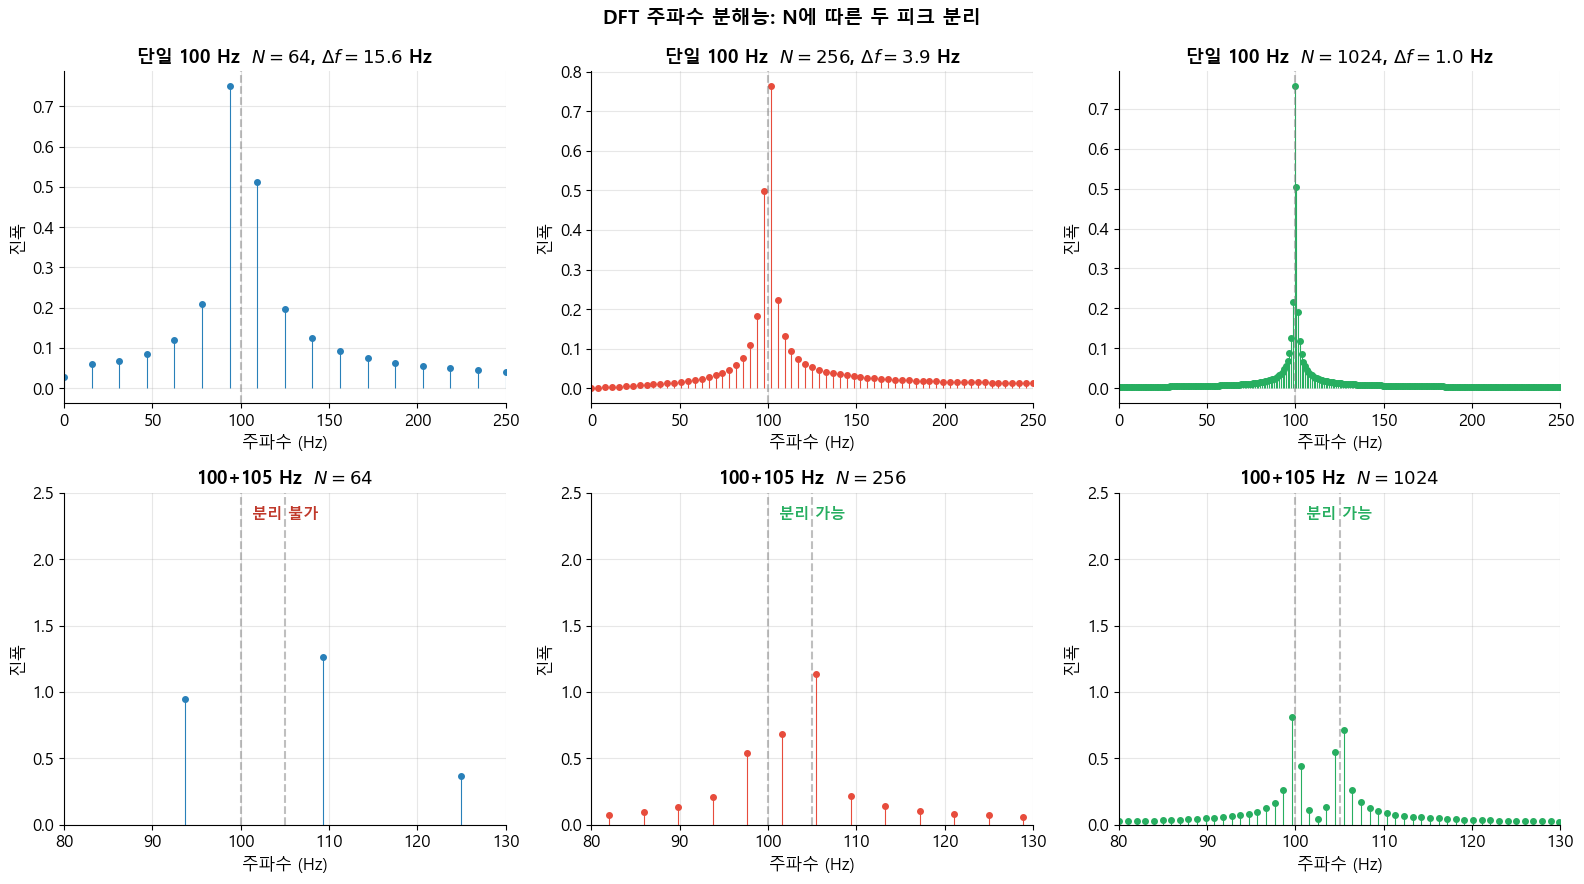

In [14]:
fs     = 1000
f1, f2 = 100, 105

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 상단: 단일 주파수
for idx, N in enumerate([64, 256, 1024]):
    t = np.arange(N) / fs
    x = np.cos(2 * np.pi * f1 * t)
    amp, freq = fft(x, fs)        # ← 공통 헬퍼
    stem_plot(axes[0, idx], freq, amp, LINE_COLORS[idx])
    axes[0, idx].set_title(f'단일 100 Hz  $N={N}$, $\Delta f={fs/N:.1f}$ Hz')
    axes[0, idx].set_xlabel('주파수 (Hz)')
    axes[0, idx].set_ylabel('진폭')
    axes[0, idx].set_xlim([0, 250])
    axes[0, idx].axvline(f1, color='gray', ls='--', alpha=0.5)

# 하단: 두 근접 주파수
for idx, N in enumerate([64, 256, 1024]):
    t = np.arange(N) / fs
    x = np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)
    amp, freq = fft(x, fs)        # ← 공통 헬퍼
    stem_plot(axes[1, idx], freq, amp, LINE_COLORS[idx])
    axes[1, idx].set_title(f'100+105 Hz  $N={N}$')
    axes[1, idx].set_xlabel('주파수 (Hz)')
    axes[1, idx].set_ylabel('진폭')
    axes[1, idx].set_xlim([80, 130]);  axes[1, idx].set_ylim([0, 2.5])
    axes[1, idx].axvline(f1, color='gray', ls='--', alpha=0.5)
    axes[1, idx].axvline(f2, color='gray', ls='--', alpha=0.5)
    ok = (fs / N) <= abs(f2 - f1)
    axes[1, idx].text(0.5, 0.92, '분리 가능' if ok else '분리 불가',
        transform=axes[1, idx].transAxes, ha='center',
        fontsize=11, fontweight='bold',
        color=LINE_COLORS[2] if ok else COLORS['warning'])

fig.suptitle('DFT 주파수 분해능: N에 따른 두 피크 분리',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**관찰**:
- **상단 행**: 단일 100 Hz 신호. $N$이 달라도 피크 위치는 일정하다.
- **하단 행**: 100 Hz + 105 Hz 혼합 신호.
  - $N=64$ ($\Delta f=15.6$ Hz): 두 피크가 하나로 합쳐진다.
  - $N=256$ ($\Delta f=3.9$ Hz $<5$ Hz): 두 피크가 분리된다.
  - $N=1024$ ($\Delta f=0.98$ Hz): 더욱 선명하게 분리된다.

**결론**: $N$ 증가 = 관측 시간 $T$ 증가 = 분해능 향상.

### 직접 해보기
1. `f1, f2 = 100, 101`로 바꾸면 1 Hz 간격을 분리하는 최소 $N$은 얼마인가?
2. 이론값 $N \geq f_s/(f_2-f_1)$과 실험 결과를 비교한다.

---
## 실습 3: 합성 음성의 FFT 스펙트럼

사람의 목소리는 **기본 주파수** $f_0$와 그 정수배인 **고조파(harmonics)**의 합으로 근사된다:

$$x(t) = \sum_{h=1}^{H} A_h \sin(2\pi h f_0 t)$$

- 모음 /a/의 기본 주파수: 약 $f_0 = 150$ Hz (남성 기준)
- FFT 스펙트럼에서 $f_0, 2f_0, 3f_0, \ldots$ 위치에 규칙적인 피크가 나타난다
- 고조파 번호가 높을수록 진폭이 작아져 풍부한 음색을 만든다

C:\Users\User\AppData\Local\Temp\ipykernel_114908\2591596639.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


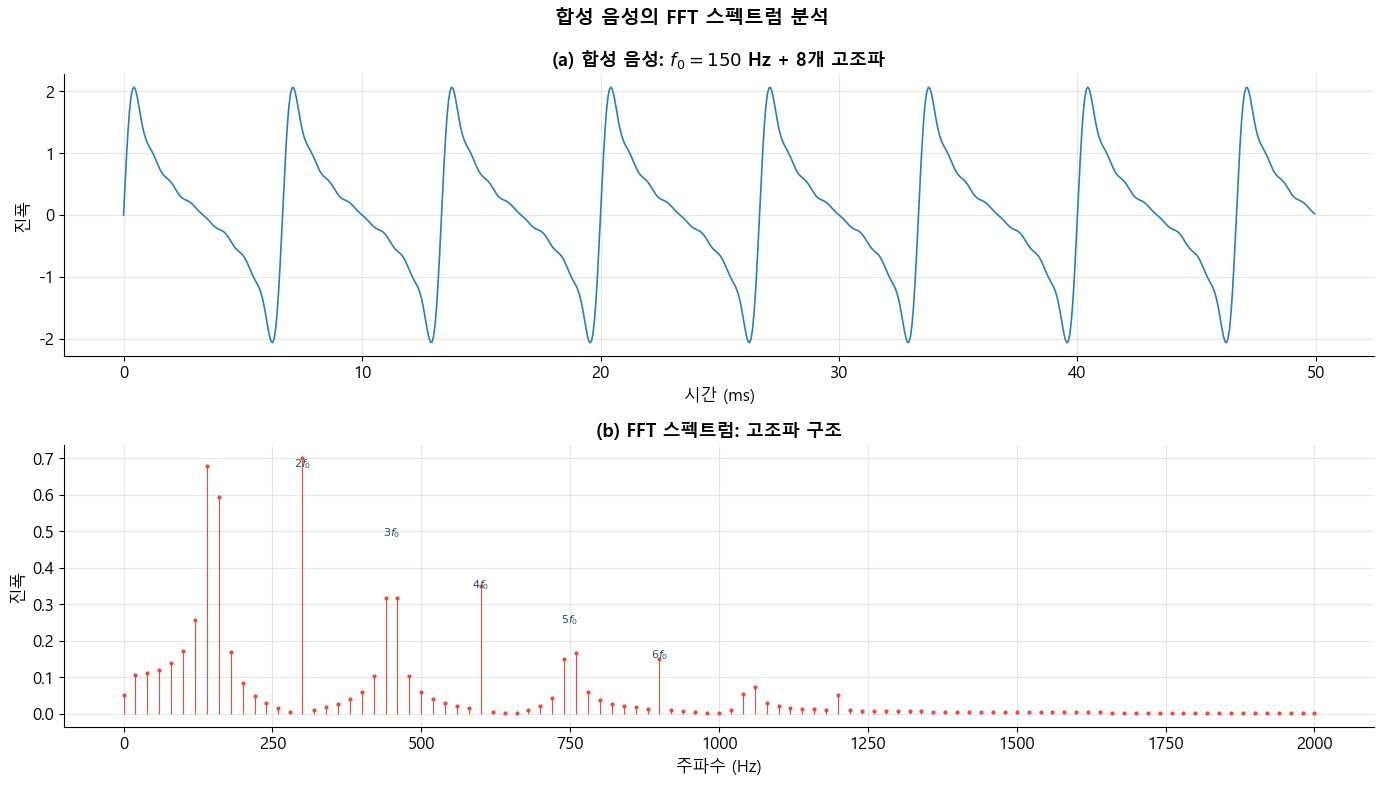

In [15]:
fs = 16000
T  = 0.05          # 50 ms 프레임
N  = int(fs * T)
t  = np.arange(N) / fs

# 합성 음성: 150 Hz + 8개 고조파 (모음 /a/ 근사)
f0        = 150
harmonics = [1, 2, 3, 4, 5, 6, 7, 8]
amps      = [1.0, 0.7, 0.5, 0.35, 0.25, 0.15, 0.1, 0.05]
x = sum(a * np.sin(2 * np.pi * f0 * h * t)
        for h, a in zip(harmonics, amps))

# FFT 단측 스펙트럼 — 공통 헬퍼
amp, freq = fft(x, fs)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# (a) 시간 영역
axes[0].plot(t * 1000, x, color=LINE_COLORS[0], lw=1.2)
axes[0].set_title(f'(a) 합성 음성: $f_0={f0}$ Hz + 8개 고조파')
axes[0].set_xlabel('시간 (ms)')
axes[0].set_ylabel('진폭')

# (b) FFT 스펙트럼 (2000 Hz 이하)
mask = freq <= 2000
stem_plot(axes[1], freq[mask], amp[mask], LINE_COLORS[1], markersize=2)
axes[1].set_title('(b) FFT 스펙트럼: 고조파 구조')
axes[1].set_xlabel('주파수 (Hz)')
axes[1].set_ylabel('진폭')
for h in harmonics[:6]:
    axes[1].annotate(
        f'${h}f_0$', xy=(f0 * h, amps[h - 1] * 0.95),
        fontsize=8, ha='center', va='bottom', color=COLORS['primary']
    )

fig.suptitle('합성 음성의 FFT 스펙트럼 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**관찰**:
- **(a)** 여러 주파수 성분이 합산되어 복잡한 파형을 형성한다. 주기 $\approx 1/f_0 = 6.67$ ms.
- **(b)** $f_0=150$ Hz, $2f_0=300$ Hz, $3f_0=450$ Hz ... 에 규칙적 피크. 고조파 번호가 클수록 진폭이 감소한다.

### 직접 해보기
1. `f0 = 200`으로 바꾸면 고조파 피크 위치가 어떻게 이동하는가?
2. `amps`를 모두 동일하게(예: 모두 `0.5`)로 바꾸면 스펙트럼 모양이 어떻게 달라지는가?

---
## 실습 4: FFT 기반 노이즈 필터링

**원리**: 주파수 영역에서 원하지 않는 성분을 제거하고 IFFT로 복원한다.

$$x_{\text{noisy}}[n]
\xrightarrow{\text{FFT}} X[k]
\xrightarrow{\text{임계값 필터}} \hat{X}[k]
\xrightarrow{\text{IFFT}} \hat{x}[n]$$

- 노이즈: 전 주파수에 골고루 분산 → 각 빈의 진폭이 작다
- 신호: 특정 주파수에 집중 → 진폭이 크다
- 임계값으로 신호와 노이즈를 분리할 수 있다

C:\Users\User\AppData\Local\Temp\ipykernel_114908\1222357966.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


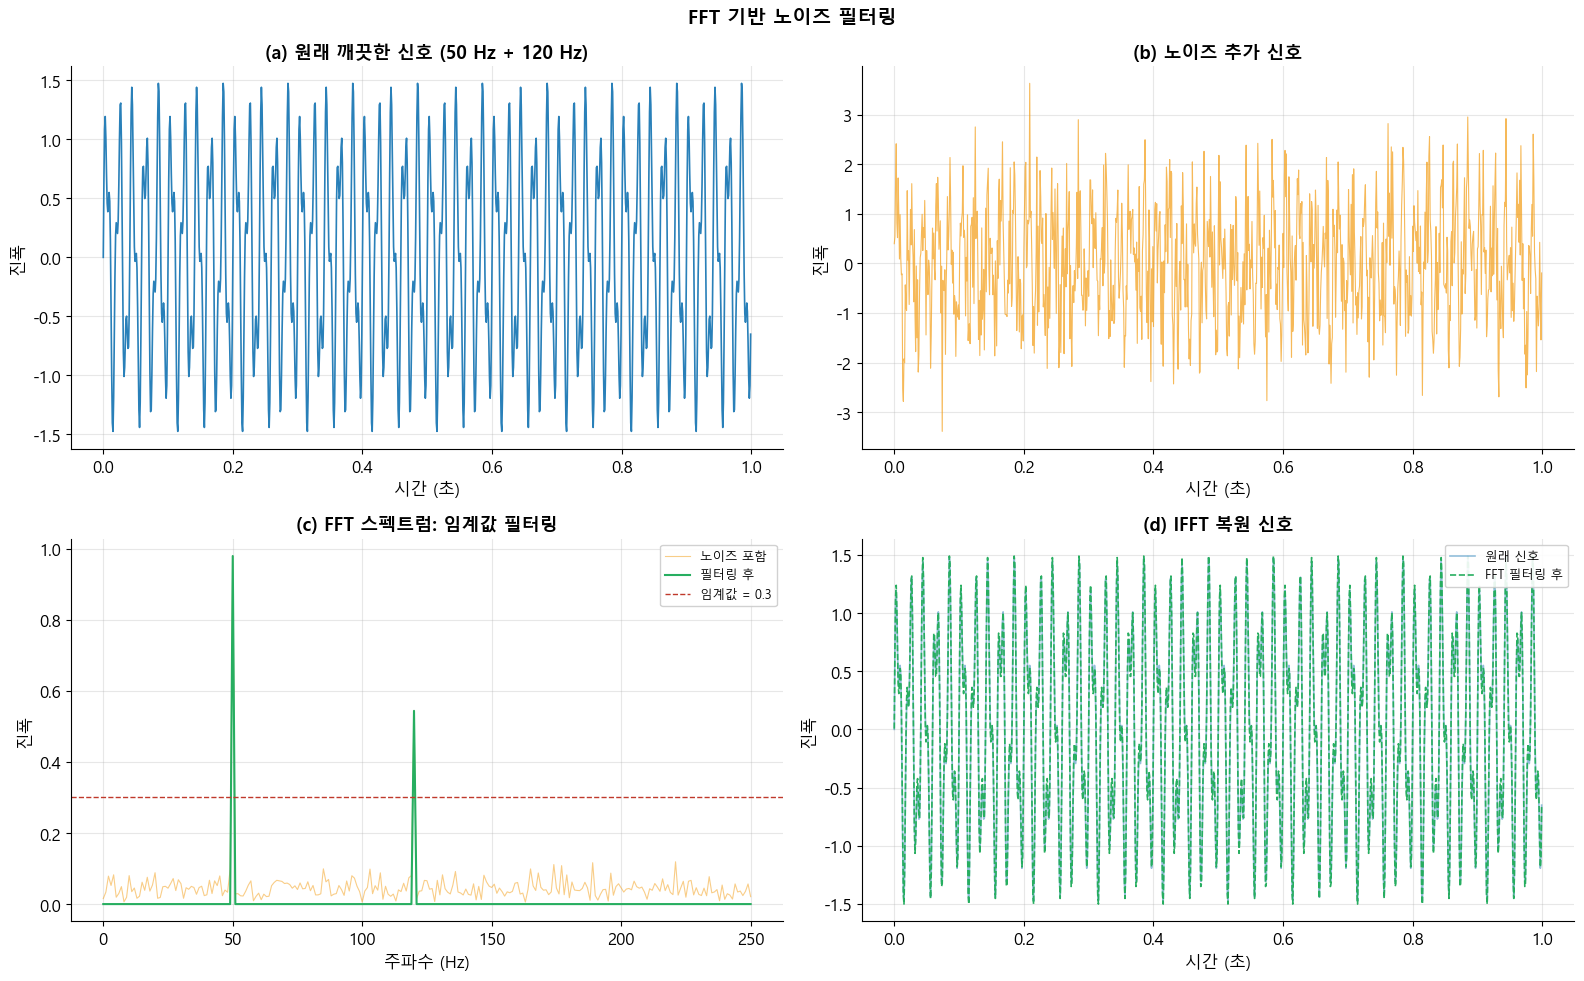

In [16]:
fs = 1000
T  = 1.0
N  = int(fs * T)
t  = np.arange(N) / fs

# 깨끗한 신호: 50 Hz + 120 Hz
x_clean = (np.sin(2 * np.pi * 50 * t)
           + 0.5 * np.sin(2 * np.pi * 120 * t))

np.random.seed(42)
x_noisy = x_clean + 0.8 * np.random.randn(N)

# (1) 스펙트럼 확인용 — 공통 헬퍼 사용
amp_n, freq = fft(x_noisy, fs)

# (2) 필터링 및 IFFT 복원은 rfft/irfft 직접 사용
#     (헬퍼는 진폭만 돌려주므로 복소 스펙트럼이 필요)
X_noisy   = np.fft.rfft(x_noisy)
threshold = 0.3
X_filt    = X_noisy.copy()
X_filt[2 * np.abs(X_filt) / N < threshold] = 0
x_filtered = np.fft.irfft(X_filt, n=N)

# 필터링 후 진폭 (시각화용)
amp_f = 2 * np.abs(X_filt) / N
amp_f[0]  /= 2
amp_f[-1] /= 2

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(t, x_clean, color=LINE_COLORS[0], lw=1.2)
axes[0, 0].set_title('(a) 원래 깨끗한 신호 (50 Hz + 120 Hz)')
axes[0, 0].set_xlabel('시간 (초)');  axes[0, 0].set_ylabel('진폭')

axes[0, 1].plot(t, x_noisy, color=LINE_COLORS[3], lw=0.8, alpha=0.7)
axes[0, 1].set_title('(b) 노이즈 추가 신호')
axes[0, 1].set_xlabel('시간 (초)');  axes[0, 1].set_ylabel('진폭')

mask = freq <= 250
axes[1, 0].plot(freq[mask], amp_n[mask], color=LINE_COLORS[3],
    lw=0.8, alpha=0.5, label='노이즈 포함')
axes[1, 0].plot(freq[mask], amp_f[mask], color=LINE_COLORS[2],
    lw=1.5, label='필터링 후')
axes[1, 0].axhline(threshold, color=COLORS['warning'], ls='--',
    lw=1, label=f'임계값 = {threshold}')
axes[1, 0].set_title('(c) FFT 스펙트럼: 임계값 필터링')
axes[1, 0].set_xlabel('주파수 (Hz)');  axes[1, 0].set_ylabel('진폭')
axes[1, 0].legend(fontsize=9)

axes[1, 1].plot(t, x_clean, color=LINE_COLORS[0], lw=1.2,
    alpha=0.5, label='원래 신호')
axes[1, 1].plot(t, x_filtered, color=LINE_COLORS[2], lw=1.2,
    ls='--', label='FFT 필터링 후')
axes[1, 1].set_title('(d) IFFT 복원 신호')
axes[1, 1].set_xlabel('시간 (초)');  axes[1, 1].set_ylabel('진폭')
axes[1, 1].legend(fontsize=9)

fig.suptitle('FFT 기반 노이즈 필터링', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**관찰**:
- **(b)** 노이즈 추가 후 원래 신호 형태를 알아보기 어렵다.
- **(c)** 50 Hz와 120 Hz 피크는 임계값 위에, 노이즈는 임계값 아래에 분포한다.
- **(d)** IFFT 복원 결과가 원래 깨끗한 신호와 거의 일치한다.

**한계**: 신호와 노이즈의 주파수 대역이 겹치면 효과가 감소한다. 더 정교한 필터링은 Ch6(디지털 필터 설계)에서 다룬다.

### 직접 해보기
1. `threshold = 0.6`으로 올리면 복원 신호가 어떻게 달라지는가?
2. 노이즈 진폭을 `0.8`에서 `0.1`로 줄이면 필터 없이도 신호를 구분할 수 있는가?

---

# 심화 학습 — 부록

아래 부록은 교재 §4.10 실습 1~5의 **보조 자료**이다. 실습을 모두 마친 후, 개념 보강·원리 심화·누설의 수치 관찰을 원할 때 참조하라.

> 참고: 원래 "부록 B: DFT 공식 직접 구현"은 학습 흐름상 **앞쪽 사전 학습**으로 이동했다.


---
## 부록 A: FT → DTFT → DFT 관계 시각화

> 본 부록은 교재 본문의 실습 목록(§4.10)에는 포함되지 않는 심화 자료이며, 교재 §4.1의 개념을 수치적으로 보조 확인한다.

교재 4.1절에서 정리한 세 변환의 핵심 차이를 같은 신호에 적용해 확인한다.

| 변환 | 시간 영역 | 주파수 영역 | 컴퓨터 계산 |
|------|-----------|-------------|-------------|
| FT   | 연속, 무한 | 연속        | 불가 |
| DTFT | 이산, 무한 | 연속        | 불가 |
| DFT  | 이산, $N$개 | 이산, $N$개 | 가능 |

**핵심**: DTFT는 FT를 이산화한 것이고, DFT는 DTFT를 유한 길이로 자른 것이다.  
DTFT를 매우 큰 $N$으로 근사하면 거의 연속 스펙트럼처럼 보이고,  
DFT는 그 연속 스펙트럼을 $N$개 점으로 샘플링한 결과이다.

C:\Users\User\AppData\Local\Temp\ipykernel_114908\1945685759.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


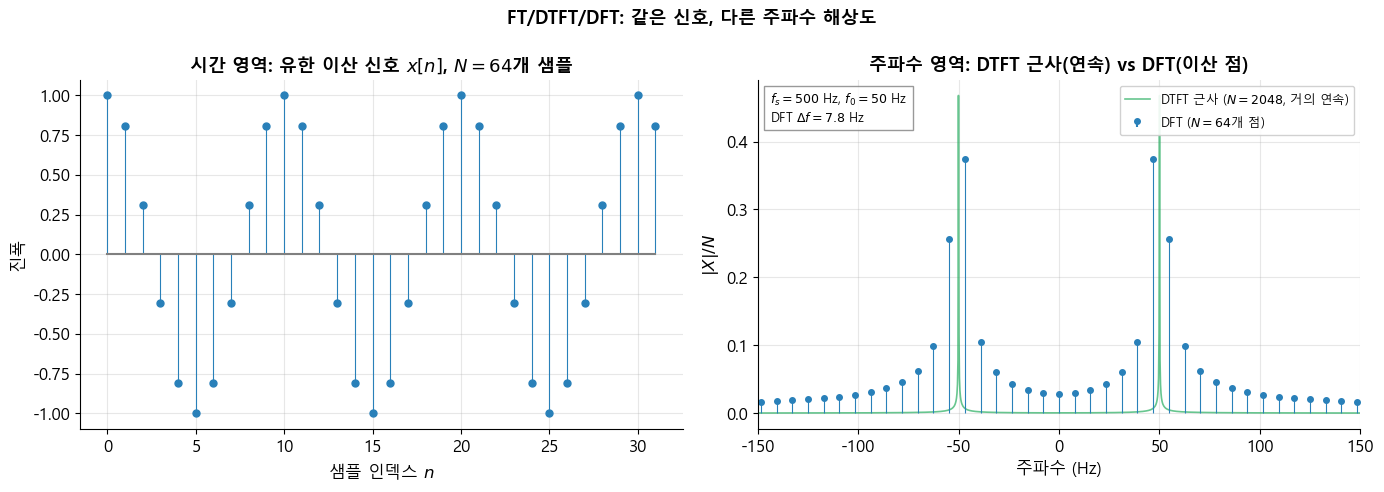

In [17]:
# 공통 파라미터
f_s = 500      # 샘플링 주파수 (Hz)
f0  = 50       # 신호 주파수 (Hz)
N   = 64       # DFT 샘플 수

# DFT: 이산 유한 N개 점
n_dft     = np.arange(N)
x_n       = np.cos(2 * np.pi * f0 * n_dft / f_s)
X_k       = np.fft.fft(x_n)
freqs_dft = np.fft.fftshift(np.fft.fftfreq(N, 1 / f_s))
mag_dft   = np.abs(np.fft.fftshift(X_k)) / N

# DTFT 근사: 큰 N으로 계산하면 거의 연속 스펙트럼
N_long     = 2048
x_long     = np.cos(2 * np.pi * f0 * np.arange(N_long) / f_s)
X_long     = np.fft.fft(x_long)
freqs_long = np.fft.fftshift(np.fft.fftfreq(N_long, 1 / f_s))
mag_long   = np.abs(np.fft.fftshift(X_long)) / N_long

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 시간 영역
markerline, stemlines, baseline = axes[0].stem(
    n_dft[:32], x_n[:32], basefmt='gray'
)
plt.setp(stemlines, color=LINE_COLORS[0], linewidth=0.8)
plt.setp(markerline, color=LINE_COLORS[0], markersize=5)
axes[0].set_title(f'시간 영역: 유한 이산 신호 $x[n]$, $N={N}$개 샘플')
axes[0].set_xlabel('샘플 인덱스 $n$')
axes[0].set_ylabel('진폭')

# 오른쪽: 주파수 영역 비교
axes[1].plot(
    freqs_long, mag_long,
    color=LINE_COLORS[2], linewidth=1.2, alpha=0.7,
    label=f'DTFT 근사 ($N={N_long}$, 거의 연속)'
)
stem_plot(axes[1], freqs_dft, mag_dft, LINE_COLORS[0],
          label=f'DFT ($N={N}$개 점)')
axes[1].set_title('주파수 영역: DTFT 근사(연속) vs DFT(이산 점)')
axes[1].set_xlabel('주파수 (Hz)')
axes[1].set_ylabel('$|X|/N$')
axes[1].set_xlim([-150, 150])
axes[1].legend(fontsize=9)
axes[1].text(
    0.02, 0.88,
    f'$f_s={f_s}$ Hz, $f_0={f0}$ Hz\nDFT $\Delta f = {f_s/N:.1f}$ Hz',
    transform=axes[1].transAxes, fontsize=9,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8)
)

fig.suptitle('FT/DTFT/DFT: 같은 신호, 다른 주파수 해상도',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**관찰**:
- DTFT 근사(파란 선): $N=2048$로 길게 계산하면 거의 연속 스펙트럼처럼 보인다. $\pm 50$ Hz에 날카로운 피크가 나타난다.
- DFT(빨간 점): $N=64$개 이산 점만으로 스펙트럼을 표현한다. 인접 점 간격은 $\Delta f = f_s/N = 500/64 \approx 7.8$ Hz이다.
- 두 결과 모두 $\pm 50$ Hz에 피크가 있어 **같은 주파수 정보**를 담는다. 차이는 주파수 축의 해상도(연속 vs 이산)뿐이다.

### 직접 해보기
1. `N = 64`를 `N = 16`으로 줄이면 DFT 점들이 얼마나 듬성듬성해지는가?
2. `N = 512`로 늘리면 DFT가 DTFT 근사에 얼마나 가까워지는가?

---
## 부록 C: DFT의 주기적 확장 가정과 스펙트럼 누설

> 심화 자료. 교재 §4.5 누설의 원인을 주기적 확장 관점에서 관찰한다.

DFT는 입력 신호가 **$N$점 주기로 무한히 반복**된다고 가정한다(교재 4.5절):

$$\tilde{x}[n] = x[n \bmod N]$$

신호의 끝과 시작이 매끄럽게 이어지면 문제없지만, 연결 지점에 **불연속**이 생기면
원래 신호에 없던 고주파 성분이 스펙트럼에 나타난다 — **스펙트럼 누설(leakage)**.

**정수 주기 조건**: $f_0 \cdot N / f_s$ 가 정수이면 끝-시작이 매끄럽게 연결된다.

C:\Users\User\AppData\Local\Temp\ipykernel_114908\1837656934.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


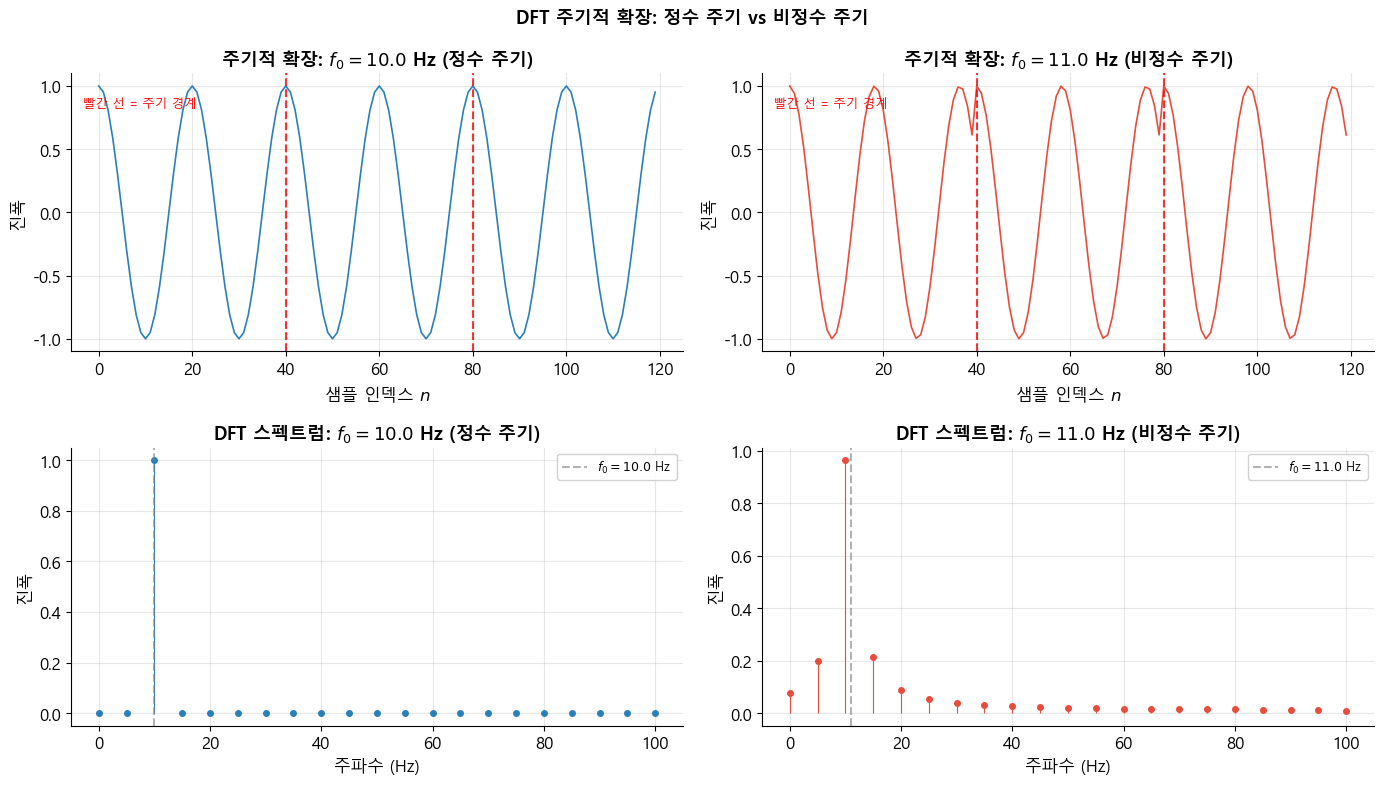

케이스 A: f0*N/fs = 2.0  (정수 → 매끄러운 연결)
케이스 B: f0*N/fs = 2.2  (비정수 → 불연속 → 누설)


In [18]:
f_s = 200
N   = 40
n   = np.arange(N)

# 케이스 A: 정수 주기  (10 * 40 / 200 = 2.0 주기)
f_A = 10.0
x_A = np.cos(2 * np.pi * f_A * n / f_s)

# 케이스 B: 비정수 주기  (11 * 40 / 200 = 2.2 주기 → 불연속)
f_B = 11.0
x_B = np.cos(2 * np.pi * f_B * n / f_s)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 위 행: 주기적 확장 시각화 (신호를 3번 반복)
for col, (x_sig, f0, label, color) in enumerate([
        (x_A, f_A, '정수 주기',   LINE_COLORS[0]),
        (x_B, f_B, '비정수 주기', LINE_COLORS[1])]):
    x_rep = np.tile(x_sig, 3)
    axes[0, col].plot(np.arange(3 * N), x_rep, color=color, lw=1.2)
    for bnd in [N, 2 * N]:
        axes[0, col].axvline(bnd, color='red', ls='--', lw=1.5, alpha=0.8)
    axes[0, col].set_title(f'주기적 확장: $f_0={f0}$ Hz ({label})')
    axes[0, col].set_xlabel('샘플 인덱스 $n$')
    axes[0, col].set_ylabel('진폭')
    axes[0, col].text(0.02, 0.88, '빨간 선 = 주기 경계',
        transform=axes[0, col].transAxes, fontsize=9, color='red')

# 아래 행: DFT 스펙트럼
for col, (x_sig, f0, label, color) in enumerate([
        (x_A, f_A, '정수 주기',   LINE_COLORS[0]),
        (x_B, f_B, '비정수 주기', LINE_COLORS[1])]):
    X_k   = np.fft.rfft(x_sig)
    freqs = np.fft.rfftfreq(N, 1 / f_s)
    amp   = 2 * np.abs(X_k) / N
    amp[0] /= 2;  amp[-1] /= 2
    stem_plot(axes[1, col], freqs, amp, color)
    axes[1, col].axvline(f0, color='gray', ls='--', alpha=0.6,
        label=f'$f_0={f0}$ Hz')
    axes[1, col].set_title(f'DFT 스펙트럼: $f_0={f0}$ Hz ({label})')
    axes[1, col].set_xlabel('주파수 (Hz)')
    axes[1, col].set_ylabel('진폭')
    axes[1, col].legend(fontsize=9)

fig.suptitle('DFT 주기적 확장: 정수 주기 vs 비정수 주기',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'케이스 A: f0*N/fs = {f_A*N/f_s:.1f}  (정수 → 매끄러운 연결)')
print(f'케이스 B: f0*N/fs = {f_B*N/f_s:.1f}  (비정수 → 불연속 → 누설)')

**관찰**:
- **정수 주기** ($f_0=10$ Hz): 주기 경계(빨간 선)에서 신호가 매끄럽게 이어진다. DFT 스펙트럼에 단 하나의 깨끗한 피크만 나타난다.
- **비정수 주기** ($f_0=11$ Hz): 경계에서 불연속이 발생한다. 스펙트럼에서 에너지가 인접 빈들로 퍼진다 — **스펙트럼 누설**.
- 이 불연속은 DFT가 신호를 $N$점으로 주기 반복한다고 가정하기 때문에 생긴다.

### 직접 해보기
1. `f_B = 10.5`로 바꾸면 $f_0 \cdot N/f_s = 2.1$이 되어 누설이 얼마나 달라지는가?
2. `N = 80`으로 늘리면 $f_B=11$ Hz에서 정수 주기 조건이 여전히 불만족인지 확인한다.

---
## 부록 D: 스펙트럼 누설 정량 관찰

> 심화 자료. 교재 §4.5에서 정성적으로 소개한 누설을 다양한 $에서 정량 관찰한다.

교재 4.5절의 **스펙트럼 누설(spectral leakage)**을 정량적으로 확인한다.

$f_0$가 DFT 빈 중심에 **정확히 놓일 때**와 **놓이지 않을 때**를 비교한다:

- **빈 중심 일치**: $f_0 = k \cdot f_s/N$ (정수 $k$) → 에너지가 한 빈에 집중
- **빈 중심 불일치**: 그 외 → 에너지가 여러 빈으로 퍼짐

Ch5에서 Hann, Hamming 등 **윈도우 함수**로 이 현상을 완화하는 방법을 배운다.

C:\Users\User\AppData\Local\Temp\ipykernel_114908\3151478297.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


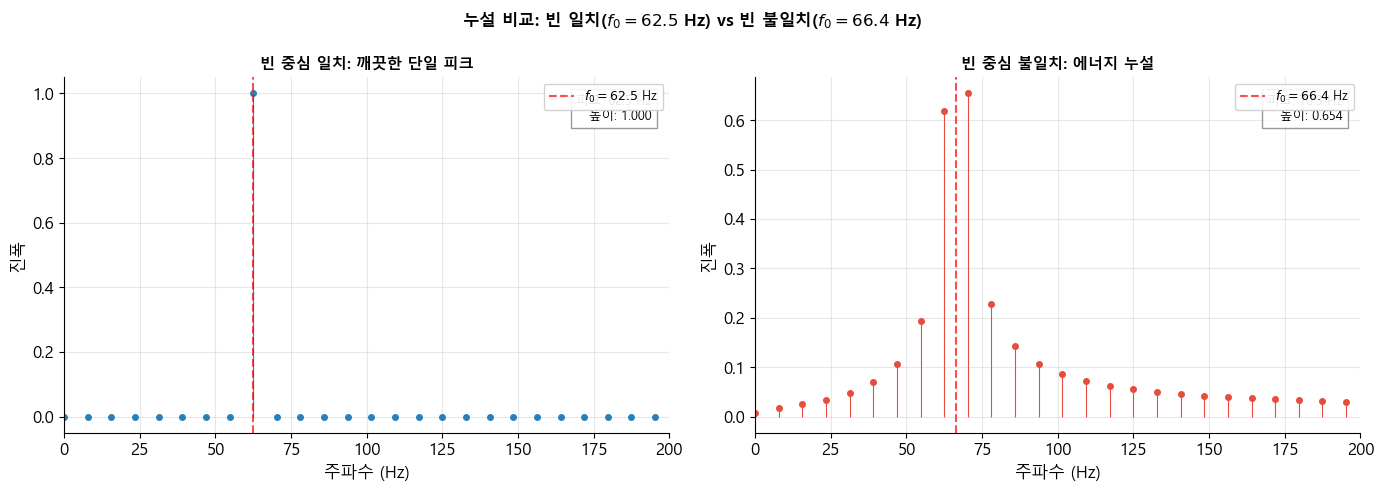

정수 빈   : f0*N/fs = 8.0  → 정수
비정수 빈 : f0*N/fs = 8.5 → 비정수 → 누설


In [19]:
f_s = 1000
N   = 128
n   = np.arange(N)

# 정수 빈: f0 = fs*8/N = 62.5 Hz  (k=8 빈 정확히)
f_int    = f_s * 8 / N
# 비정수 빈: k=8.5 사이에 위치 → 누설 발생
f_nonint = f_s * 8.5 / N

x_int    = np.cos(2 * np.pi * f_int    * n / f_s)
x_nonint = np.cos(2 * np.pi * f_nonint * n / f_s)

freqs = np.fft.rfftfreq(N, 1 / f_s)

def one_sided_amp(x):
    X   = np.fft.rfft(x)
    amp = 2 * np.abs(X) / len(x)
    amp[0] /= 2;  amp[-1] /= 2
    return amp

amp_int    = one_sided_amp(x_int)
amp_nonint = one_sided_amp(x_nonint)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, amp, f0, title, color in [
    (axes[0], amp_int,    f_int,    '빈 중심 일치: 깨끗한 단일 피크', LINE_COLORS[0]),
    (axes[1], amp_nonint, f_nonint, '빈 중심 불일치: 에너지 누설',   LINE_COLORS[1]),
]:
    stem_plot(ax, freqs, amp, color)
    ax.axvline(f0, color='red', ls='--', alpha=0.7,
               label=f'$f_0={f0:.1f}$ Hz')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('주파수 (Hz)')
    ax.set_ylabel('진폭')
    ax.set_xlim([0, 200])
    ax.legend(fontsize=9)
    pk = np.argmax(amp)
    ax.text(0.97, 0.88,
        f'피크: {freqs[pk]:.1f} Hz\n높이: {amp[pk]:.3f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

fig.suptitle(
    f'누설 비교: 빈 일치($f_0={f_int:.1f}$ Hz) vs 빈 불일치($f_0={f_nonint:.1f}$ Hz)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'정수 빈   : f0*N/fs = {f_int*N/f_s:.1f}  → 정수')
print(f'비정수 빈 : f0*N/fs = {f_nonint*N/f_s:.1f} → 비정수 → 누설')

**관찰**:
- **빈 중심 일치** ($f_0 \cdot N/f_s$ = 정수): 에너지가 단 하나의 빈에 완전히 집중된다. 피크 높이 $\approx 1.0$으로 원래 진폭과 일치한다.
- **빈 중심 불일치**: 에너지가 인접 빈들로 퍼진다. 피크 높이가 낮아지고 주변에 스커트(skirt) 형태의 잔류 에너지가 보인다.
- 이것이 **스펙트럼 누설**이다. Ch5에서 윈도우 함수(Hann 등)로 누설을 크게 줄이는 방법을 배운다.

### 직접 해보기
1. `f_nonint = f_s * 8.5 / N`을 `f_s * 8.1 / N`으로 바꾸면 누설이 줄어드는가?
2. `x_nonint * np.hanning(N)`으로 Hann 윈도우를 적용하면 스펙트럼이 어떻게 달라지는가?

---
## 정리

| 실습 | 핵심 개념 | 결과 |
|------|-----------|------|
| 0 | FT/DTFT/DFT 관계 | 같은 신호, 다른 주파수 해상도 |
| 1 | DFT 직접 구현 | 수동 DFT = FFT (오차 $\sim 10^{-12}$) |
| 2 | 양측/단측 스펙트럼 | cos → $\pm f_0$ 대칭; rfft로 단측 변환 |
| 3 | 주파수 분해능 | $\Delta f = f_s/N$; $N$ 클수록 세밀한 분리 |
| 4 | 주기적 확장 | 정수 주기 → 깨끗, 비정수 주기 → 누설 |
| 5 | fftfreq / fftshift | fftfreq 구조 이해; fftshift로 단조 정렬 |
| 6 | 스펙트럼 누설 | 빈 불일치 → 에너지 확산; 윈도우로 완화 |
| 7 | 합성 음성 FFT | 고조파 구조가 스펙트럼에 명확히 나타남 |
| 8 | FFT 필터링 | 임계값 필터링 + IFFT로 노이즈 제거 |

### 핵심 수식

**DFT 정의** (식 4.4):
$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N}$$

**주파수 대응**:
$$f_k = k \cdot \frac{f_s}{N}, \quad \Delta f = \frac{f_s}{N} = \frac{1}{T}$$

**단측 스펙트럼** (실수 신호, $k \neq 0, N/2$):
$$A_k = \frac{2|X[k]|}{N}$$

### NumPy FFT 함수

```python
np.fft.fft(x)            # DFT — 복소수, 길이 N
np.fft.ifft(X)           # IDFT
np.fft.rfft(x)           # 실수 신호 DFT — 길이 N//2+1
np.fft.irfft(X, n=N)     # 실수 신호 IDFT
np.fft.fftfreq(N, 1/fs)  # 주파수 축
np.fft.rfftfreq(N, 1/fs) # 단측 주파수 축
np.fft.fftshift(X)       # 양측 스펙트럼 정렬
```